In [8]:
# LIBRARIES IMPORT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import ipywidgets as widgets
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [7]:
# LOAD DATASET

# Display the upload button
uploader = widgets.FileUpload(accept=".csv", multiple=False)
display(uploader)

FileUpload(value=(), accept='.csv', description='Upload')

In [10]:
#BASIC INSPECTION

print(df.head())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
# DATA QUALITY CHECK

print("Missing Values Count:")
print(df.isnull().sum().max())  

Missing Values Count:
0


In [4]:
# FEATURE ENGINEERING (BRAND EXTRACTION)

df['Brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())
df['Brand'] = df['Brand'].replace({
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
})

num_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
df['doornumber'] = df['doornumber'].map(num_map)
df['cylindernumber'] = df['cylindernumber'].map(num_map)

df.drop(columns=['car_ID', 'CarName'], inplace=True)

print("Dataset After Feature engineering:")
print(df.head())

Dataset After Feature engineering:
   symboling fueltype aspiration  doornumber      carbody drivewheel  \
0          3      gas        std           2  convertible        rwd   
1          3      gas        std           2  convertible        rwd   
2          1      gas        std           2    hatchback        rwd   
3          2      gas        std           4        sedan        fwd   
4          2      gas        std           4        sedan        4wd   

  enginelocation  wheelbase  carlength  carwidth  ...  fuelsystem  boreratio  \
0          front       88.6      168.8      64.1  ...        mpfi       3.47   
1          front       88.6      168.8      64.1  ...        mpfi       3.47   
2          front       94.5      171.2      65.5  ...        mpfi       2.68   
3          front       99.8      176.6      66.2  ...        mpfi       3.19   
4          front       99.4      176.6      66.4  ...        mpfi       3.19   

  stroke  compressionratio  horsepower peakrpm  cit

C:\Users\smmblz\AppData\Local\Temp\ipykernel_1676\2755241708.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')


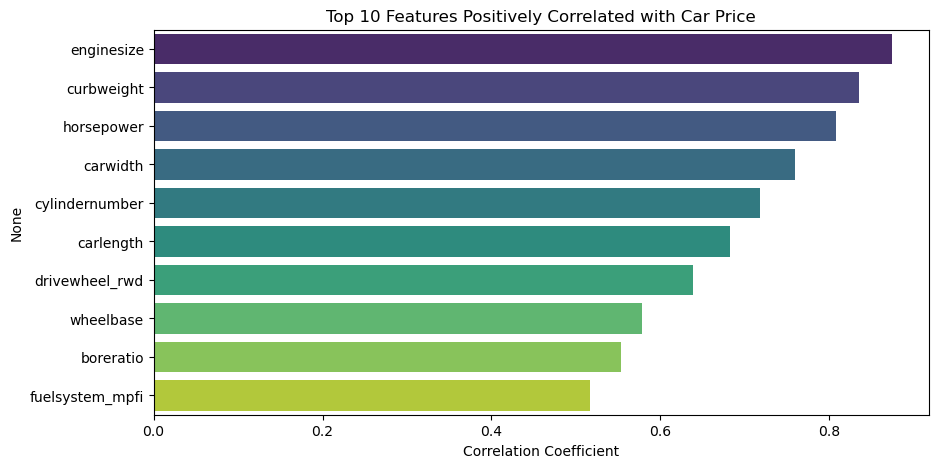

In [5]:
# CELL 4: ONE-HOT ENCODING & VISUALIZATION

categorical_cols = ['Brand', 'fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'fuelsystem']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

plt.figure(figsize=(10, 5))
top_corr = df_encoded.corr()['price'].sort_values(ascending=False)[1:11]
sns.barplot(x=top_corr.values, y=top_corr.index, palette='viridis')
plt.title("Top 10 Features Positively Correlated with Car Price")
plt.xlabel("Correlation Coefficient")
plt.show()

In [6]:
# TRAIN/TEST SPLIT & FEATURE SCALING

X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#REGRESSION MODELS TRAINING & EVALUATION

models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })

comparison_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

print("=" * 60)
print("\t\t REGRESSION MODELS EVALUATION")
print("=" * 60)
print(comparison_df.to_string(index=False))

		 REGRESSION MODELS EVALUATION
                      Model  R2 Score  MAE ($)  RMSE ($)
    Random Forest Regressor    0.9586  1288.69   1808.72
Gradient Boosting Regressor    0.9272  1680.31   2397.17


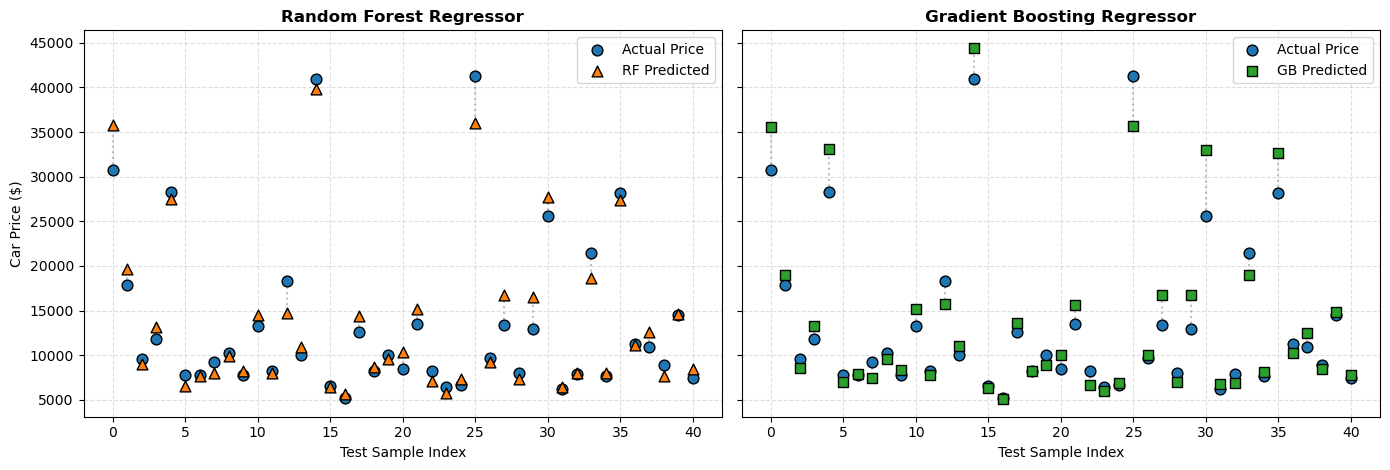

In [8]:
#  SIDE-BY-SIDE MODEL COMPARISON (RF vs GB)

rf_pred = models["Random Forest Regressor"].predict(X_test_scaled)
gb_pred = models["Gradient Boosting Regressor"].predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
indices = np.arange(len(y_test))

# 1. Random Forest Plot
axes[0].scatter(indices, y_test.values, color='#1f77b4', s=60, label='Actual Price', edgecolors='k', zorder=3)
axes[0].scatter(indices, rf_pred, color='#ff7f0e', s=60, marker='^', label='RF Predicted', edgecolors='k', zorder=3)
for i in range(len(y_test)):
    axes[0].plot([indices[i], indices[i]], [y_test.values[i], rf_pred[i]], color='gray', linestyle=':', alpha=0.5)
axes[0].set_title("Random Forest Regressor", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Test Sample Index", fontsize=10)
axes[0].set_ylabel("Car Price ($)", fontsize=10)
axes[0].legend(frameon=True, facecolor='white')
axes[0].grid(True, linestyle='--', alpha=0.4)

# 2. Gradient Boosting Plot
axes[1].scatter(indices, y_test.values, color='#1f77b4', s=60, label='Actual Price', edgecolors='k', zorder=3)
axes[1].scatter(indices, gb_pred, color='#2ca02c', s=60, marker='s', label='GB Predicted', edgecolors='k', zorder=3)
for i in range(len(y_test)):
    axes[1].plot([indices[i], indices[i]], [y_test.values[i], gb_pred[i]], color='gray', linestyle=':', alpha=0.5)
axes[1].set_title("Gradient Boosting Regressor", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Test Sample Index", fontsize=10)
axes[1].legend(frameon=True, facecolor='white')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

C:\Users\smmblz\AppData\Local\Temp\ipykernel_1676\2083768933.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp.values, y=rf_imp.index, ax=axes[0], palette='mako')
C:\Users\smmblz\AppData\Local\Temp\ipykernel_1676\2083768933.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gb_imp.values, y=gb_imp.index, ax=axes[1], palette='viridis')


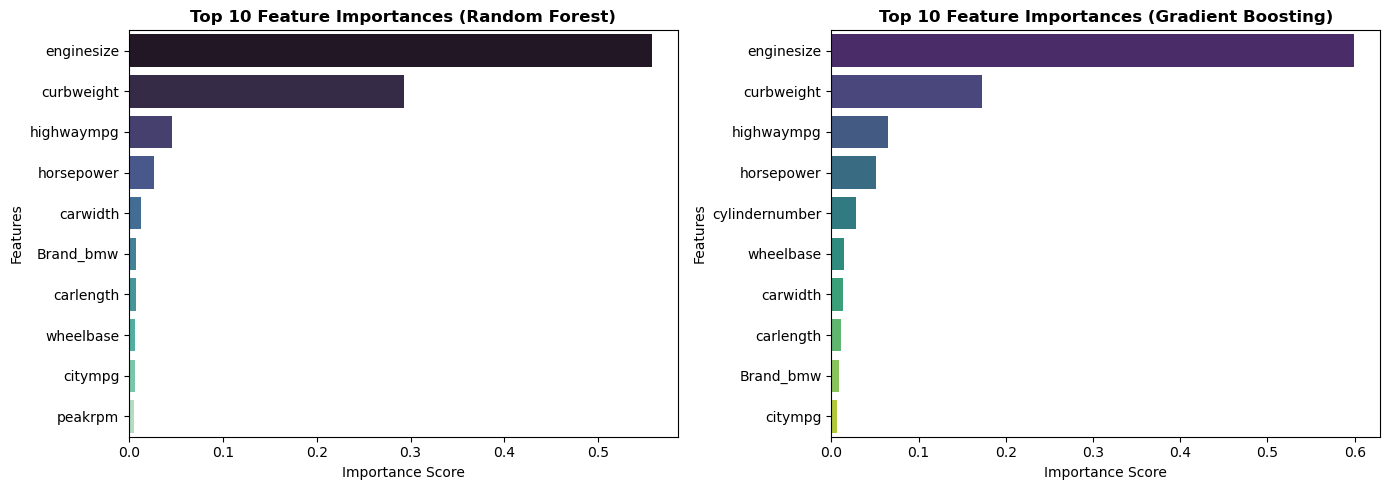

In [9]:
#FEATURE IMPORTANCE (RF vs GB)

rf_model = models["Random Forest Regressor"]
gb_model = models["Gradient Boosting Regressor"]

rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
gb_imp = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Plot
sns.barplot(x=rf_imp.values, y=rf_imp.index, ax=axes[0], palette='mako')
axes[0].set_title("Top 10 Feature Importances (Random Forest)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Importance Score", fontsize=10)
axes[0].set_ylabel("Features", fontsize=10)

# Gradient Boosting Plot
sns.barplot(x=gb_imp.values, y=gb_imp.index, ax=axes[1], palette='viridis')
axes[1].set_title("Top 10 Feature Importances (Gradient Boosting)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Importance Score", fontsize=10)
axes[1].set_ylabel("Features", fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
#  MULTI-SAMPLE CAR PRICE INFERENCE

num_samples = 5
results_table = []

for i in range(num_samples):
    sample = X_test_scaled[i].reshape(1, -1)
    actual_price = y_test.iloc[i]
    
    row = {
        "Test Sample": f"Car #{i+1}",
        "Actual Price ($)": f"${actual_price:,.2f}"
    }
    
    for name, model in models.items():
        pred_val = model.predict(sample)[0]
        row[name] = f"${pred_val:,.2f}"
        
    results_table.append(row)

multi_sample_df = pd.DataFrame(results_table)

print("=" * 85)
print(" \tMULTI-SAMPLE CAR PRICE PREDICTIONS ACROSS REGRESSION MODELS ")
print("=" * 85)
print(multi_sample_df.to_string(index=False))
print("=" * 85)

 	MULTI-SAMPLE CAR PRICE PREDICTIONS ACROSS REGRESSION MODELS 
Test Sample Actual Price ($) Random Forest Regressor Gradient Boosting Regressor
     Car #1       $30,760.00              $35,821.98                  $35,573.54
     Car #2       $17,859.17              $19,619.61                  $18,976.17
     Car #3        $9,549.00               $8,992.32                   $8,555.04
     Car #4       $11,850.00              $13,186.97                  $13,227.72
     Car #5       $28,248.00              $27,460.40                  $33,051.49


In [11]:
# CAR PRICE PREDICTOR BY USER_INPUT

def predict_combined_car_price():
    print("=" * 65)
    print(" \tENTER CAR SPECIFICATIONS FOR FINAL PRICE ESTIMATE ")
    print("=" * 65)
    
    try:
        brand = input("1. Enter Brand (e.g., toyota, bmw, audi, honda, mazda): ").strip().lower() or 'toyota'
        horsepower = float(input("2. Enter Horsepower (e.g., 68 to 288): ") or 100)
        enginesize = float(input("3. Enter Engine Size (e.g., 60 to 326): ") or 120)
        curbweight = float(input("4. Enter Curb Weight in lbs (e.g., 1488 to 4066): ") or 2400)
        highwaympg = float(input("5. Enter Highway Mileage - MPG (e.g., 16 to 54): ") or 30)
        citympg = float(input("6. Enter City Mileage - MPG (e.g., 13 to 49): ") or 24)
        carbody = input("7. Enter Body Style (sedan / hatchback / convertible / wagon / hardtop): ").strip().lower() or 'sedan'
        fueltype = input("8. Enter Fuel Type (gas / diesel): ").strip().lower() or 'gas'
    except ValueError:
        print("\n❌ Invalid input detected. Using default reference car.")
        horsepower, enginesize, curbweight, highwaympg, citympg = 100, 120, 2400, 30, 24
        brand, carbody, fueltype = 'toyota', 'sedan', 'gas'

    user_data = pd.DataFrame(0.0, index=[0], columns=X.columns)
    user_data['horsepower'] = horsepower
    user_data['enginesize'] = enginesize
    user_data['curbweight'] = curbweight
    user_data['highwaympg'] = highwaympg
    user_data['citympg'] = citympg
    user_data['wheelbase'] = X['wheelbase'].mean()
    user_data['carlength'] = X['carlength'].mean()
    user_data['carwidth'] = X['carwidth'].mean()
    user_data['carheight'] = X['carheight'].mean()
    user_data['boreratio'] = X['boreratio'].mean()
    user_data['stroke'] = X['stroke'].mean()
    user_data['compressionratio'] = X['compressionratio'].mean()
    user_data['peakrpm'] = X['peakrpm'].mean()
    user_data['doornumber'] = 4
    user_data['cylindernumber'] = 4
    
    # Set One-Hot Encoded flags
    brand_col = f"Brand_{brand}"
    if brand_col in user_data.columns:
        user_data[brand_col] = 1.0
        
    body_col = f"carbody_{carbody}"
    if body_col in user_data.columns:
        user_data[body_col] = 1.0
        
    fuel_col = f"fueltype_{fueltype}"
    if fuel_col in user_data.columns:
        user_data[fuel_col] = 1.0

    user_scaled = scaler.transform(user_data)
    rf_price = models["Random Forest Regressor"].predict(user_scaled)[0]
    gb_price = models["Gradient Boosting Regressor"].predict(user_scaled)[0]
    
    # Combined Consensus (Average of RF and GB)
    final_combined_price = (rf_price + gb_price) / 2
    min_est = min(rf_price, gb_price)
    max_est = max(rf_price, gb_price)

    # Output Card
    print("\n" + "=" * 65)
    print(" FINAL VEHICLE PRICE VALUATION (ENSEMBLE CONSENSUS) ")
    print("=" * 65)
    print(f" • Specification : {brand.upper()} ({carbody.capitalize()}) | {int(horsepower)} HP | {fueltype.upper()}")
    print(f" • Fuel Economy  : {int(citympg)} City / {int(highwaympg)} Highway MPG")
    print("-" * 65)
    print(f" RECOMMENDED MARKET PRICE : ${final_combined_price:,.2f}")
    print(f" Expected Valuation Range  : ${min_est:,.2f} – ${max_est:,.2f}")
    print("=" * 65)

# Function call 
predict_combined_car_price()

 	ENTER CAR SPECIFICATIONS FOR FINAL PRICE ESTIMATE 


1. Enter Brand (e.g., toyota, bmw, audi, honda, mazda):  bmw
2. Enter Horsepower (e.g., 68 to 288):  200
3. Enter Engine Size (e.g., 60 to 326):  250
4. Enter Curb Weight in lbs (e.g., 1488 to 4066):  3500
5. Enter Highway Mileage - MPG (e.g., 16 to 54):  45
6. Enter City Mileage - MPG (e.g., 13 to 49):  39
7. Enter Body Style (sedan / hatchback / convertible / wagon / hardtop):  convertible
8. Enter Fuel Type (gas / diesel):  diesel



 FINAL VEHICLE PRICE VALUATION (ENSEMBLE CONSENSUS) 
 • Specification : BMW (Convertible) | 200 HP | DIESEL
 • Fuel Economy  : 39 City / 45 Highway MPG
-----------------------------------------------------------------
 RECOMMENDED MARKET PRICE : $32,605.54
 Expected Valuation Range  : $31,299.09 – $33,911.99
